In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm", "-q"])
print("Dependencies ready.")

Dependencies ready.


In [2]:
import os
import sys
import json
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
from PIL import Image

try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()} | Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")
print(f"tqdm     : ok")

PyTorch  : 2.6.0+cu118
CUDA     : True | Device: NVIDIA GeForce RTX 3060
tqdm     : ok


In [3]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print(f"Seed set to {SEED}")

Seed set to 42


In [ ]:
CFG = {
    "data_dir":        "F:\\ChromeDownloads\\IMG_CLASSES_Task",
    "output_dir":      "F:\\ExcelTech-Take Home\\output",
    "checkpoint_dir":  "F:\\ExcelTech-Take Home\\ckpt",

    "model_name":      "efficientnet_v2_m",
    "num_classes":     10,
    "image_size":      480,

    "stage1_epochs":   10,     # frozen backbone, head only
    "stage2_epochs":   30,    # progressive unfreeze
    "batch_size":      16,
    "accum_steps":     2,     
    "num_workers":     0,

    
    "head_lr":         1e-3,
    "backbone_lr":     1e-5,
    "head_lr_s2":      1e-4,
    "weight_decay":    1e-4,

    
    "warmup_epochs":   2,
    "min_lr":          1e-7,

    
    "label_smoothing": 0.1,
    "cutmix_alpha":    1.0,   
    "dropout":         0.4,

    
    "patience":        7,

    "tta_n":           5,     
}

In [5]:
CLASS_NAMES = [
    "Eczema",
    "Warts Molluscum and other Viral Infections",
    "Melanoma",
    "Atopic Dermatitis",
    "Basal Cell Carcinoma",
    "Melanocytic Nevi",
    "Benign Keratosis-like Lesions",
    "Psoriasis pictures Lichen Planus and related diseases",
    "Seborrheic Keratoses and other Benign Tumors",
    "Tinea Ringworm Candidiasis and other Fungal Infections",
]

SHORT_NAMES = [
    "Eczema", "Viral Infections", "Melanoma", "Atopic Dermatitis",
    "Basal Cell Ca.", "Melanocytic Nevi", "Benign Keratosis",
    "Psoriasis/LP", "Seborrheic Keratoses", "Tinea/Fungal",
]

MALIGNANT_INDICES = {2, 4}

In [ ]:
def get_transforms(split: str, image_size: int = 480):
    
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if split == "train":
        return transforms.Compose([
            transforms.Resize((image_size + 32, image_size + 32)),
            transforms.RandomCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(
                brightness=0.3,
                contrast=0.3,
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

    return transforms.Compose([
        transforms.Resize((image_size + 32, image_size + 32)),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

In [ ]:
def get_tta_transform(image_size: int = 480):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    return transforms.Compose([
        transforms.Resize((image_size + 32, image_size + 32)),
        transforms.RandomCrop(image_size),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

In [ ]:
def cutmix_batch(images: torch.Tensor, labels: torch.Tensor, alpha: float = 1.0):
    if alpha <= 0:
        return images, labels, labels, 1.0

    lam = np.random.beta(alpha, alpha)
    B, C, H, W = images.shape
    index = torch.randperm(B, device=images.device)

    cut_ratio = np.sqrt(1.0 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)
    cy = np.random.randint(H)
    cx = np.random.randint(W)
    y1 = max(cy - cut_h // 2, 0)
    y2 = min(cy + cut_h // 2, H)
    x1 = max(cx - cut_w // 2, 0)
    x2 = min(cx + cut_w // 2, W)

    mixed = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[index, :, y1:y2, x1:x2]

    lam = 1.0 - (y2 - y1) * (x2 - x1) / (H * W)

    return mixed, labels, labels[index], lam


def cutmix_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)

In [ ]:
def build_model(num_classes: int, dropout: float = 0.4, freeze_backbone: bool = True):
    model = models.efficientnet_v2_m(
        weights=models.EfficientNet_V2_M_Weights.IMAGENET1K_V1
    )

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features  # 1280 for V2-M
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 512),
        nn.SiLU(),
        nn.Dropout(p=dropout * 0.7),
        nn.Linear(512, num_classes),
    )
    return model

In [ ]:
def unfreeze_blocks(model, block_indices: list):
    for i in block_indices:
        for param in model.features[i].parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Unfroze blocks {block_indices} | Trainable: {trainable:,} / {total:,} params")

In [ ]:
class CustomSkinDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


def load_datasets(data_dir: str, image_size: int = 480):
    all_image_paths, all_labels = [], []

    classes = sorted(entry.name for entry in os.scandir(data_dir) if entry.is_dir())
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

    print(f"  Found {len(classes)} classes in {data_dir}")
    print(f"  {'Class':<30} {'Total':>7}")
    print(f"  {'-'*38}")
    for cls_name in classes:
        cls_dir = os.path.join(data_dir, cls_name)
        img_paths = [
            os.path.join(cls_dir, f)
            for f in os.listdir(cls_dir)
            if f.lower().endswith(('png', 'jpg', 'jpeg', 'bmp', 'gif', 'webp'))
        ]
        all_image_paths.extend(img_paths)
        all_labels.extend([class_to_idx[cls_name]] * len(img_paths))
        print(f"  {cls_name:<30} {len(img_paths):>7}")
    print(f"  {'='*38}")
    print(f"  {'Total':<30} {len(all_image_paths):>7}\n")

    # Stratified 80 / 20
    train_paths, temp_paths, train_labels, temp_labels = train_test_split(
        all_image_paths, all_labels,
        test_size=0.2, stratify=all_labels, random_state=SEED
    )
    # Stratified 50 / 50 on the 20% remainder
    val_paths, test_paths, val_labels, test_labels = train_test_split(
        temp_paths, temp_labels,
        test_size=0.5, stratify=temp_labels, random_state=SEED
    )

    def _counts(labels):
        c = Counter(labels)
        return [c.get(i, 0) for i in range(len(classes))]

    tc, vc, tec = _counts(train_labels), _counts(val_labels), _counts(test_labels)
    tot = [a + b + c for a, b, c in zip(tc, vc, tec)]
    print(f"  Stratified split verification:")
    print(f"  {'Class':<25} {'Train(80%)':>10} {'Val(10%)':>9} {'Test(10%)':>10} {'Total':>7}")
    print(f"  {'-'*63}")
    for i, name in enumerate(SHORT_NAMES):
        pct = tc[i] / tot[i] * 100 if tot[i] else 0
        print(f"  {name:<25} {tc[i]:>7}({pct:.0f}%) {vc[i]:>8}   {tec[i]:>9}   {tot[i]:>7}")
    print(f"  {'='*63}")
    print(f"  {'TOTAL':<25} {len(train_labels):>10} {len(val_labels):>9} {len(test_labels):>10} {len(all_labels):>7}")
    print(f"\n  Imbalance correction: WeightedRandomSampler on train loader only.")

    train_ds = CustomSkinDataset(train_paths, train_labels,
                                 transform=get_transforms("train", image_size))
    val_ds   = CustomSkinDataset(val_paths,   val_labels,
                                 transform=get_transforms("val", image_size))
    test_ds  = CustomSkinDataset(test_paths,  test_labels,
                                 transform=get_transforms("test", image_size))

    train_ds.samples = list(zip(train_paths, train_labels))
    val_ds.samples   = list(zip(val_paths,   val_labels))
    test_ds.samples  = list(zip(test_paths,  test_labels))

    test_ds.raw_paths  = test_paths
    test_ds.raw_labels = test_labels

    return train_ds, val_ds, test_ds

In [ ]:
def get_weighted_sampler(dataset):
    labels = [label for _, label in dataset.samples]
    class_counts = Counter(labels)
    class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in labels]
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )

In [ ]:
def get_scheduler(optimizer, warmup_epochs, total_epochs, min_lr):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / max(warmup_epochs, 1)
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        cosine   = 0.5 * (1 + np.cos(np.pi * progress))
        base_lr  = optimizer.param_groups[0]["initial_lr"]
        floor    = min_lr / max(base_lr, 1e-10)
        return max(cosine, floor)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler, cutmix_alpha=1.0, accum_steps=2):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="Training", leave=False, file=sys.stdout)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        mixed, labels_a, labels_b, lam = cutmix_batch(images, labels, cutmix_alpha)

        optimizer.zero_grad()
        
        with torch.autocast(device_type='cuda'):
            logits = model(mixed)
            loss   = cutmix_criterion(criterion, logits, labels_a, labels_b, lam)
        
        scaler.scale(loss).backward()
        
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (lam * (preds == labels_a).float() +
                       (1 - lam) * (preds == labels_b).float()).sum().item()
        total      += images.size(0)
        pbar.set_postfix({"loss": f"{total_loss/total:.4f}", "acc": f"{correct/total:.3f}"})

    return total_loss / total, correct / total

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    pbar = tqdm(loader, desc="Evaluating", leave=False, file=sys.stdout)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        pbar.set_postfix({"loss": f"{total_loss/total:.4f}", "acc": f"{correct/total:.3f}"})

    acc      = correct / total
    avg_loss = total_loss / total
    f1       = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, acc, f1, np.array(all_preds), np.array(all_labels), np.array(all_probs)

In [ ]:
@torch.no_grad()
def predict_tta(model, pil_image, tta_transform, n: int = 5, device="cpu"):
    model.eval()
    probs_list = []
    for _ in range(n):
        aug    = tta_transform(pil_image).unsqueeze(0).to(device)
        logits = model(aug)
        probs_list.append(F.softmax(logits, dim=1))
    return torch.stack(probs_list).mean(dim=0).squeeze(0)


@torch.no_grad()
def evaluate_tta(model, test_dataset, tta_transform, criterion, device, n_tta=5):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    raw_paths  = test_dataset.raw_paths
    raw_labels = test_dataset.raw_labels

    pbar = tqdm(
        zip(raw_paths, raw_labels),
        total=len(raw_paths),
        desc=f"TTA Eval (n={n_tta})",
        leave=False,
        file=sys.stdout,
    )
    for img_path, label in pbar:
        pil_img   = Image.open(img_path).convert('RGB')
        avg_probs = predict_tta(model, pil_img, tta_transform, n=n_tta, device=device)
        pred      = avg_probs.argmax().item()

        all_preds.append(pred)
        all_labels.append(label)
        all_probs.append(avg_probs.cpu().numpy())

        running_acc = np.mean(np.array(all_preds) == np.array(all_labels))
        pbar.set_postfix({"acc": f"{running_acc:.3f}"})

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc = (all_preds == all_labels).mean()
    f1  = f1_score(all_labels, all_preds, average="weighted")

    return 0.0, acc, f1, all_preds, all_labels, all_probs

In [17]:
class EarlyStopping:
    def __init__(self, patience: int = 7, min_delta: float = 1e-4, mode: str = "max"):
        self.patience    = patience
        self.min_delta   = min_delta
        self.mode        = mode
        self.best        = None
        self.counter     = 0
        self.should_stop = False

    def step(self, value: float) -> bool:
        if self.best is None:
            self.best = value
            return False
        improved = (value > self.best + self.min_delta) if self.mode == "max" \
              else (value < self.best - self.min_delta)
        if improved:
            self.best    = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

In [ ]:
def train(cfg: dict = CFG):
    device = torch.device("cuda" if torch.cuda.is_available() else
                          "mps"  if torch.backends.mps.is_available() else "cpu")
    print(f"\nDevice: {device}")

    os.makedirs(cfg["output_dir"],     exist_ok=True)
    os.makedirs(cfg["checkpoint_dir"], exist_ok=True)

    # ── Data ──────────────────────────────────────────────────────────
    print("\nLoading datasets...")
    train_ds, val_ds, test_ds = load_datasets(cfg["data_dir"], cfg["image_size"])

    sampler = get_weighted_sampler(train_ds)  

    train_loader = DataLoader(
        train_ds, batch_size=cfg["batch_size"],
        sampler=sampler,     
        num_workers=cfg["num_workers"], pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg["batch_size"],
        shuffle=False,       
        num_workers=cfg["num_workers"], pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds, batch_size=cfg["batch_size"],
        shuffle=False,       
        num_workers=cfg["num_workers"], pin_memory=True,
    )

    criterion = nn.CrossEntropyLoss(
        label_smoothing=cfg["label_smoothing"],
    )

    scaler = torch.amp.GradScaler('cuda')
    
    print(f"\n{'═'*62}")
    print(f"STAGE 1 — Head training ({cfg['stage1_epochs']} epochs) [EfficientNetV2-M]")
    print(f"{'═'*62}")

    model = build_model(cfg["num_classes"], cfg["dropout"], freeze_backbone=True).to(device)
    total_params    = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parameters: {total_params:,} total | {trainable_params:,} trainable (head only)")

    optimizer = torch.optim.AdamW(
        model.classifier.parameters(),
        lr=cfg["head_lr"], weight_decay=cfg["weight_decay"],
    )
    for g in optimizer.param_groups:
        g["initial_lr"] = g["lr"]

    scheduler     = get_scheduler(optimizer, cfg["warmup_epochs"],
                                  cfg["stage1_epochs"], cfg["min_lr"])
    early_stopper = EarlyStopping(patience=cfg["patience"], mode="max")

    best_val_f1 = 0.0
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [], "val_f1": []
    }
     
    for epoch in range(cfg["stage1_epochs"]):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler, cfg["cutmix_alpha"], cfg["accum_steps"]
        )
        vl_loss, vl_acc, vl_f1, _, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)

        lr_now = optimizer.param_groups[0]["lr"]
        print(f"  Ep {epoch+1:02d}/{cfg['stage1_epochs']} | "
              f"tr_loss {tr_loss:.4f} tr_acc {tr_acc:.3f} | "
              f"vl_loss {vl_loss:.4f} vl_acc {vl_acc:.3f} vl_f1 {vl_f1:.3f} | "
              f"lr {lr_now:.2e} | {time.time()-t0:.1f}s")
        sys.stdout.flush()

        if vl_f1 > best_val_f1:
            best_val_f1 = vl_f1
            torch.save(model.state_dict(),
                       os.path.join(cfg["checkpoint_dir"], "best_stage1.pt"))

        if early_stopper.step(vl_f1):
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(
        torch.load(os.path.join(cfg["checkpoint_dir"], "best_stage1.pt"),
                   map_location=device)
    )

    
    print(f"\n{'═'*62}")
    print(f"STAGE 2 — Progressive unfreeze ({cfg['stage2_epochs']} epochs) [EfficientNetV2-M]")
    print(f"{'═'*62}")

    unfreeze_schedule = {
        0:  [8, 7],      # Epoch  0: deepest MBConv + head conv
        5:  [6, 5],      # Epoch  5: mid-deep MBConv
        12: [4, 3],      # Epoch 12: shallow MBConv + first Fused block
        20: [2, 1, 0],   # Epoch 20: remaining Fused-MBConv + stem
    }

    optimizer = torch.optim.AdamW([
        {"params": model.classifier.parameters(), "lr": cfg["head_lr_s2"]},
        {"params": model.features.parameters(),   "lr": cfg["backbone_lr"]},
    ], weight_decay=cfg["weight_decay"])
    for g in optimizer.param_groups:
        g["initial_lr"] = g["lr"]

    scheduler     = get_scheduler(optimizer, cfg["warmup_epochs"],
                                  cfg["stage2_epochs"], cfg["min_lr"])
    early_stopper = EarlyStopping(patience=cfg["patience"], mode="max")
    best_val_f1   = 0.0

    for epoch in range(cfg["stage2_epochs"]):
        if epoch in unfreeze_schedule:
            unfreeze_blocks(model, unfreeze_schedule[epoch])

        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scaler, cfg["cutmix_alpha"], cfg["accum_steps"]
        )
        vl_loss, vl_acc, vl_f1, _, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        history["val_f1"].append(vl_f1)

        lr_now = optimizer.param_groups[0]["lr"]
        print(f"  Ep {epoch+1:02d}/{cfg['stage2_epochs']} | "
              f"tr_loss {tr_loss:.4f} tr_acc {tr_acc:.3f} | "
              f"vl_loss {vl_loss:.4f} vl_acc {vl_acc:.3f} vl_f1 {vl_f1:.3f} | "
              f"lr {lr_now:.2e} | {time.time()-t0:.1f}s")
        sys.stdout.flush()

        if vl_f1 > best_val_f1:
            best_val_f1 = vl_f1
            torch.save(model.state_dict(),
                       os.path.join(cfg["checkpoint_dir"], "best_model.pt"))
            print(f"  ✓ New best val F1: {best_val_f1:.4f}")

        if early_stopper.step(vl_f1):
            print(f"  Early stopping at epoch {epoch+1}")
            break

    print(f"\n{'═'*62}")
    print("FINAL EVALUATION — Test set with TTA")
    print(f"{'═'*62}")

    model.load_state_dict(
        torch.load(os.path.join(cfg["checkpoint_dir"], "best_model.pt"),
                   map_location=device)
    )
    model.eval()

    tta_transform = get_tta_transform(cfg["image_size"])

    print("\n[1/2] Single-pass evaluation (baseline)...")
    _, test_acc_base, test_f1_base, preds_base, labels, probs_base = evaluate(
        model, test_loader, criterion, device
    )
    print(f"  Single-pass — Accuracy: {test_acc_base:.4f} | Weighted F1: {test_f1_base:.4f}")

    print(f"\n[2/2] TTA evaluation (n={cfg['tta_n']} passes per image)...")
    _, test_acc_tta, test_f1_tta, preds, _, probs = evaluate_tta(
        model, test_ds, tta_transform, criterion, device, n_tta=cfg["tta_n"]
    )
    print(f"  TTA          — Accuracy: {test_acc_tta:.4f} | Weighted F1: {test_f1_tta:.4f}")
    print(f"  TTA gain     — Accuracy: +{(test_acc_tta - test_acc_base)*100:.2f}pp | "
          f"F1: +{(test_f1_tta - test_f1_base)*100:.2f}pp")

    print(f"\nFinal Test Accuracy  : {test_acc_tta:.4f}")
    print(f"Final Test W-F1      : {test_f1_tta:.4f}")

    print("\nPer-class Classification Report (TTA):")
    print(classification_report(labels, preds, target_names=SHORT_NAMES, digits=3))

    try:
        auc = roc_auc_score(
            np.eye(cfg["num_classes"])[labels], probs, multi_class="ovr"
        )
        print(f"Macro ROC-AUC (TTA): {auc:.4f}")
    except Exception as e:
        print(f"ROC-AUC skipped: {e}")

    print("\nMalignant class performance (TTA):")
    for idx in MALIGNANT_INDICES:
        tp   = ((preds == idx) & (labels == idx)).sum()
        fp   = ((preds == idx) & (labels != idx)).sum()
        fn   = ((preds != idx) & (labels == idx)).sum()
        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        print(f"  {SHORT_NAMES[idx]:<20} precision={prec:.3f}  recall={rec:.3f}")

    results = {
        "model":                 "efficientnet_v2_m",
        "image_size":            cfg["image_size"],
        "augmentation":          "cutmix",
        "tta_n":                 cfg["tta_n"],
        "test_accuracy_single":  round(test_acc_base, 4),
        "test_accuracy_tta":     round(test_acc_tta,  4),
        "test_weighted_f1_single": round(test_f1_base, 4),
        "test_weighted_f1_tta":  round(test_f1_tta,   4),
        "best_val_f1":           round(best_val_f1,   4),
    }
    with open(os.path.join(cfg["output_dir"], "results.json"), "w") as f:
        json.dump(results, f, indent=2)
    print("\nResults JSON:")
    print(json.dumps(results, indent=2))
    sys.stdout.flush()

    _plot_confusion_matrix(labels, preds, cfg["output_dir"])
    _plot_training_curves(history, cfg["output_dir"], cfg["stage1_epochs"])
    _plot_per_class_f1(labels, preds, cfg["output_dir"])

    print(f"\nAll outputs saved to: {cfg['output_dir']}/")
    return model, history, results

In [19]:
def _plot_confusion_matrix(labels, preds, out_dir):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".1f"],
        ["Raw counts", "Row-normalised (%)"],
    ):
        sns.heatmap(
            data, ax=ax, annot=True, fmt=fmt, cmap="Blues",
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.4, cbar=True,
        )
        ax.set_title(title, fontsize=13, pad=12)
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True",      fontsize=11)
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

    plt.suptitle(
        "Confusion Matrix — EfficientNetV2-M | CutMix | TTA",
        fontsize=15, y=1.01
    )
    plt.tight_layout()
    path = os.path.join(out_dir, "confusion_matrix.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")
    plt.show()
    plt.close()

In [ ]:
def _plot_training_curves(history, out_dir, stage1_epochs):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1: Loss
    axes[0].plot(epochs, history["train_loss"], label="Train", color="steelblue")
    axes[0].plot(epochs, history["val_loss"],   label="Val",   color="tomato")
    axes[0].set_title("Train vs Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Panel 2: Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train Acc", color="steelblue")
    axes[1].plot(epochs, history["val_acc"],   label="Val Acc",   color="tomato")
    axes[1].set_title("Train vs Val Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    # Panel 3: Val F1
    axes[2].plot(epochs, history["val_f1"], color="mediumseagreen", label="Val F1")
    axes[2].set_title("Validation Weighted F1")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()

    for ax in axes:
        ax.axvline(x=stage1_epochs, color="gray", linestyle="--",
                   alpha=0.6, label="Stage 2 start")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle("Training Curves — EfficientNetV2-M | CutMix", fontsize=13)
    plt.tight_layout()
    path = os.path.join(out_dir, "training_curves.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")
    plt.show()
    plt.close()

In [21]:
def _plot_per_class_f1(labels, preds, out_dir):
    report = classification_report(
        labels, preds, target_names=SHORT_NAMES, output_dict=True
    )
    f1s    = [report[name]["f1-score"]  for name in SHORT_NAMES]
    precs  = [report[name]["precision"] for name in SHORT_NAMES]
    recs   = [report[name]["recall"]    for name in SHORT_NAMES]
    colors = ["#e74c3c" if i in MALIGNANT_INDICES else "#3498db"
              for i in range(len(SHORT_NAMES))]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    for ax, values, xlabel, col in zip(
        axes,
        [f1s,      precs,       recs],
        ["F1 Score", "Precision", "Recall"],
        [colors,   colors,      colors],
    ):
        bars = ax.barh(SHORT_NAMES, values, color=col, edgecolor="white", height=0.65)
        ax.set_xlim(0, 1.0)
        ax.set_xlabel(xlabel)
        ax.axvline(x=np.mean(values), color="gray", linestyle="--", alpha=0.7,
                   label=f"Mean = {np.mean(values):.3f}")
        ax.legend(fontsize=8)
        ax.grid(axis="x", alpha=0.3)
        for bar, val in zip(bars, values):
            ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", fontsize=8)

    axes[0].set_title("Per-class F1 Score")
    axes[1].set_title("Per-class Precision")
    axes[2].set_title("Per-class Recall")

    plt.suptitle(
        "Per-class Metrics — EfficientNetV2-M | CutMix | TTA\n(red = malignant classes)",
        fontsize=13
    )
    plt.tight_layout()
    path = os.path.join(out_dir, "per_class_metrics.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved: {path}")
    plt.show()
    plt.close()


Device: cuda

Loading datasets...
  Found 10 classes in F:\ChromeDownloads\IMG_CLASSES_Task
  Class                            Total
  --------------------------------------
  1. Eczema 1677                    1677
  10. Warts Molluscum and other Viral Infections - 2103    2103
  2. Melanoma 15.75k                3140
  3. Atopic Dermatitis - 1.25k      1257
  4. Basal Cell Carcinoma (BCC) 3323    3323
  5. Melanocytic Nevi (NV) - 7970    7970
  6. Benign Keratosis-like Lesions (BKL) 2624    2079
  7. Psoriasis pictures Lichen Planus and related diseases - 2k    2055
  8. Seborrheic Keratoses and other Benign Tumors - 1.8k    1847
  9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k    1702
  Total                            27153

  Stratified split verification:
  Class                     Train(80%)  Val(10%)  Test(10%)   Total
  ---------------------------------------------------------------
  Eczema                       1342(80%)      168         167      1677
  Vi

Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/170 [00:00<?, ?it/s]

  Ep 01/10 | tr_loss 1.9090 tr_acc 0.344 | vl_loss 1.3490 vl_acc 0.607 vl_f1 0.598 | lr 1.00e-03 | 626.1s


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

...

  Ep 29/30 | tr_loss 1.1128 tr_acc 0.704 | vl_loss 0.7539 vl_acc 0.901 vl_f1 0.901 | lr 3.14e-07 | 917.2s
  Early stopping at epoch 29

══════════════════════════════════════════════════════════════
FINAL EVALUATION — Test set with TTA
══════════════════════════════════════════════════════════════

[1/2] Single-pass evaluation (baseline)...


Evaluating:   0%|          | 0/170 [00:00<?, ?it/s]

  Single-pass — Accuracy: 0.8932 | Weighted F1: 0.8930

[2/2] TTA evaluation (n=5 passes per image)...


TTA Eval (n=5):   0%|          | 0/2716 [00:00<?, ?it/s]

  TTA          — Accuracy: 0.9017 | Weighted F1: 0.9018
  TTA gain     — Accuracy: +0.85pp | F1: +0.88pp

Final Test Accuracy  : 0.9017
Final Test W-F1      : 0.9018

Per-class Classification Report (TTA):
                      precision    recall  f1-score   support

              Eczema      0.811     0.772     0.791       167
    Viral Infections      0.796     0.853     0.824       211
            Melanoma      0.997     1.000     0.998       314
   Atopic Dermatitis      0.642     0.688     0.664       125
      Basal Cell Ca.      0.931     0.973     0.952       333
    Melanocytic Nevi      0.989     0.975     0.982       797
    Benign Keratosis      0.892     0.875     0.883       208
        Psoriasis/LP      0.829     0.752     0.789       206
Seborrheic Keratoses      0.861     0.870     0.866       185
        Tinea/Fungal      0.829     0.829     0.829       170

            accuracy                          0.902      2716
           macro avg      0.858     0.859     0.

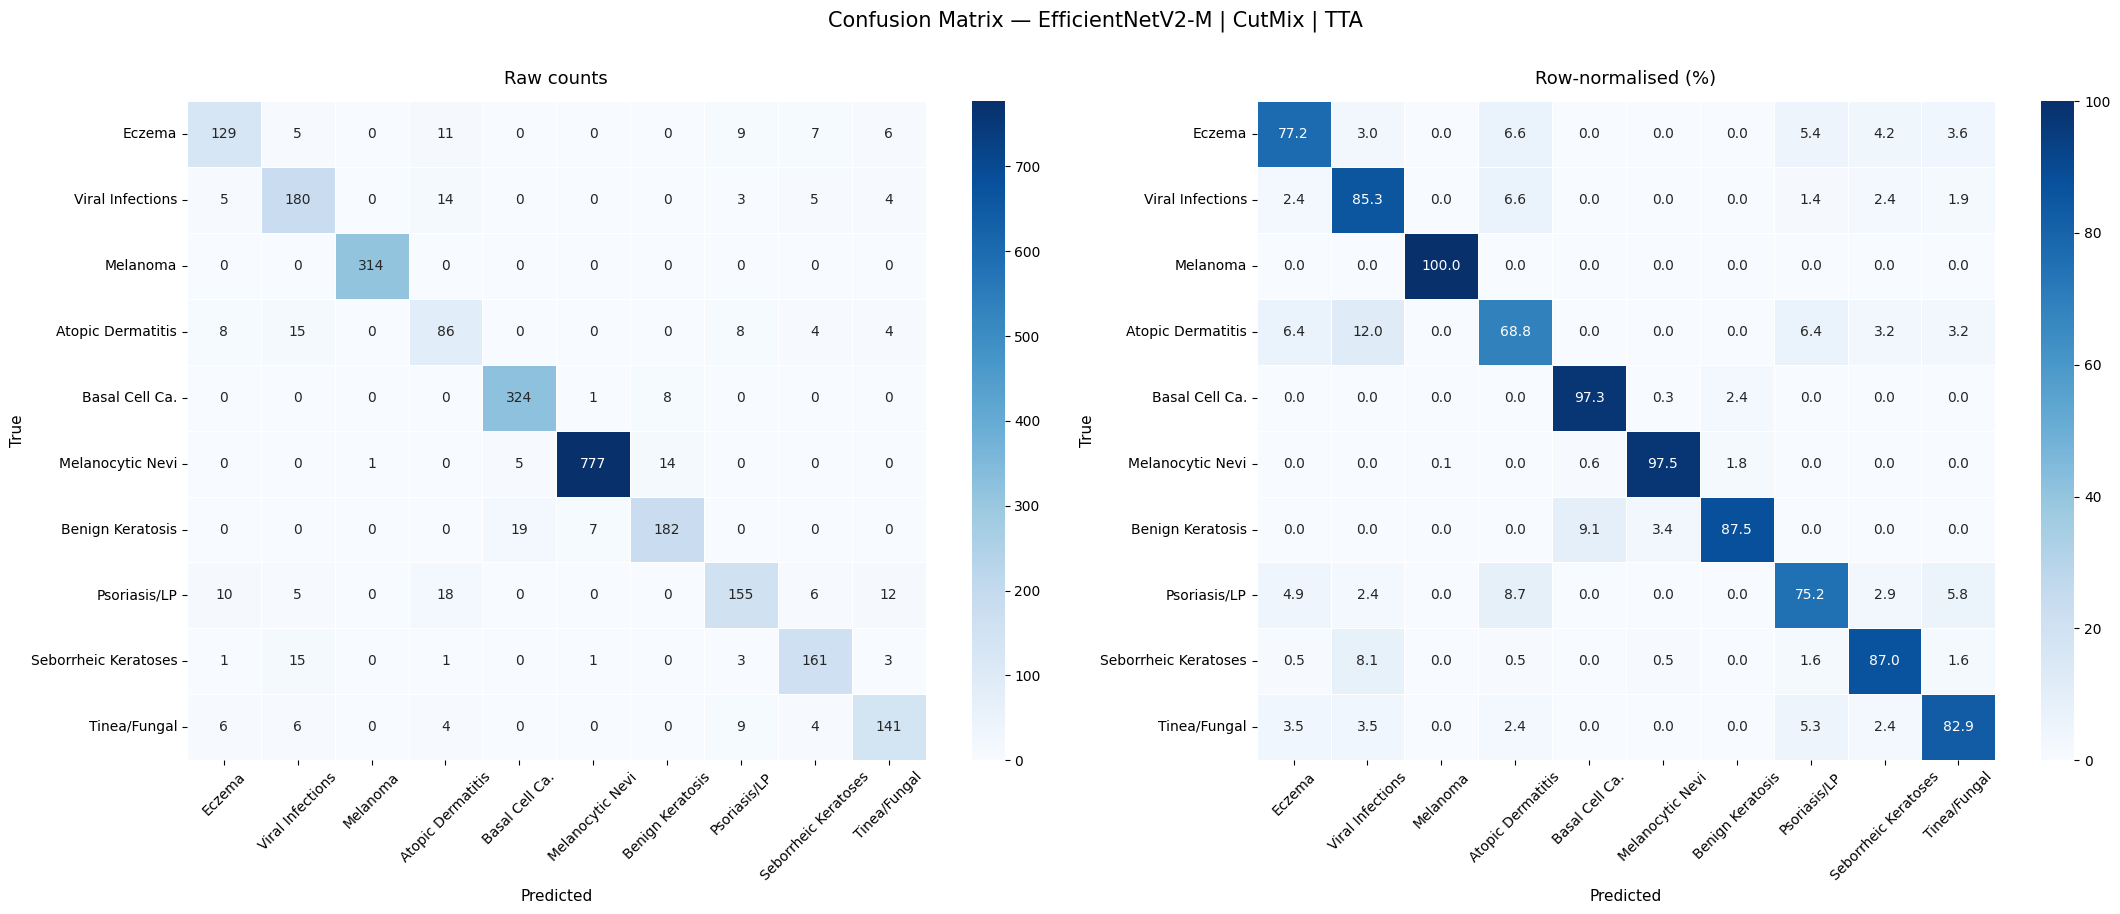

  Saved: F:\ExcelTech-Take Home\output\training_curves.png


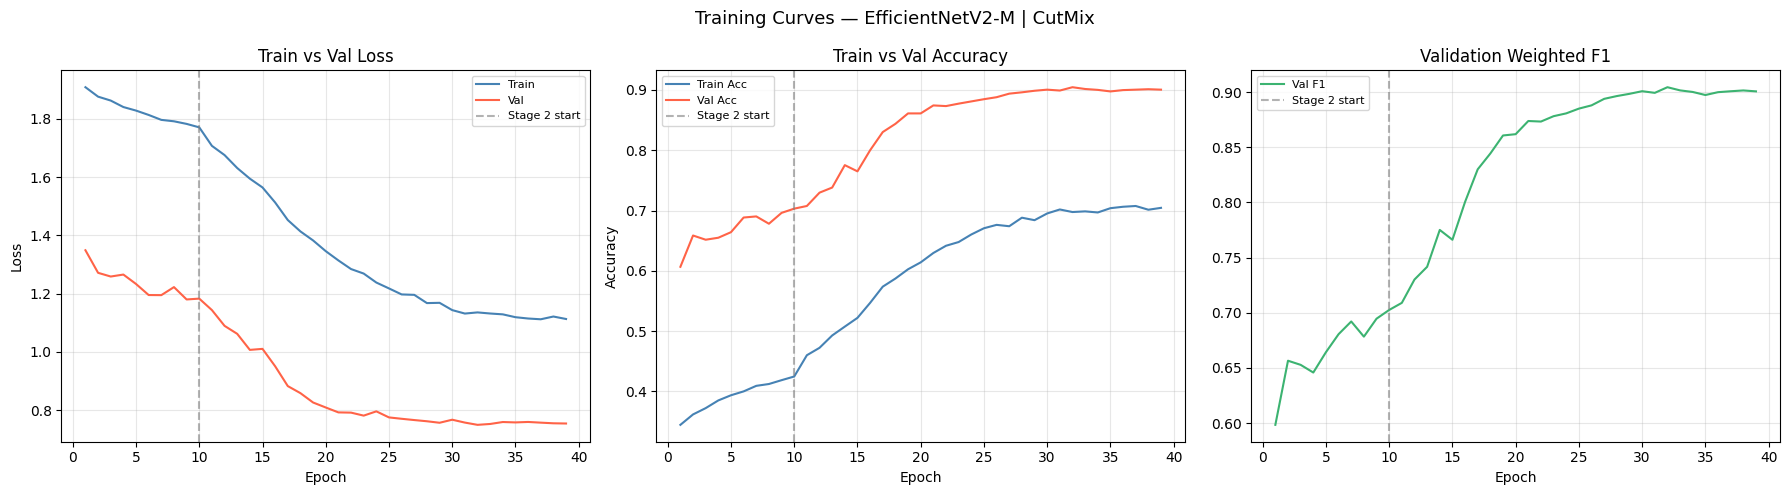

  Saved: F:\ExcelTech-Take Home\output\per_class_metrics.png


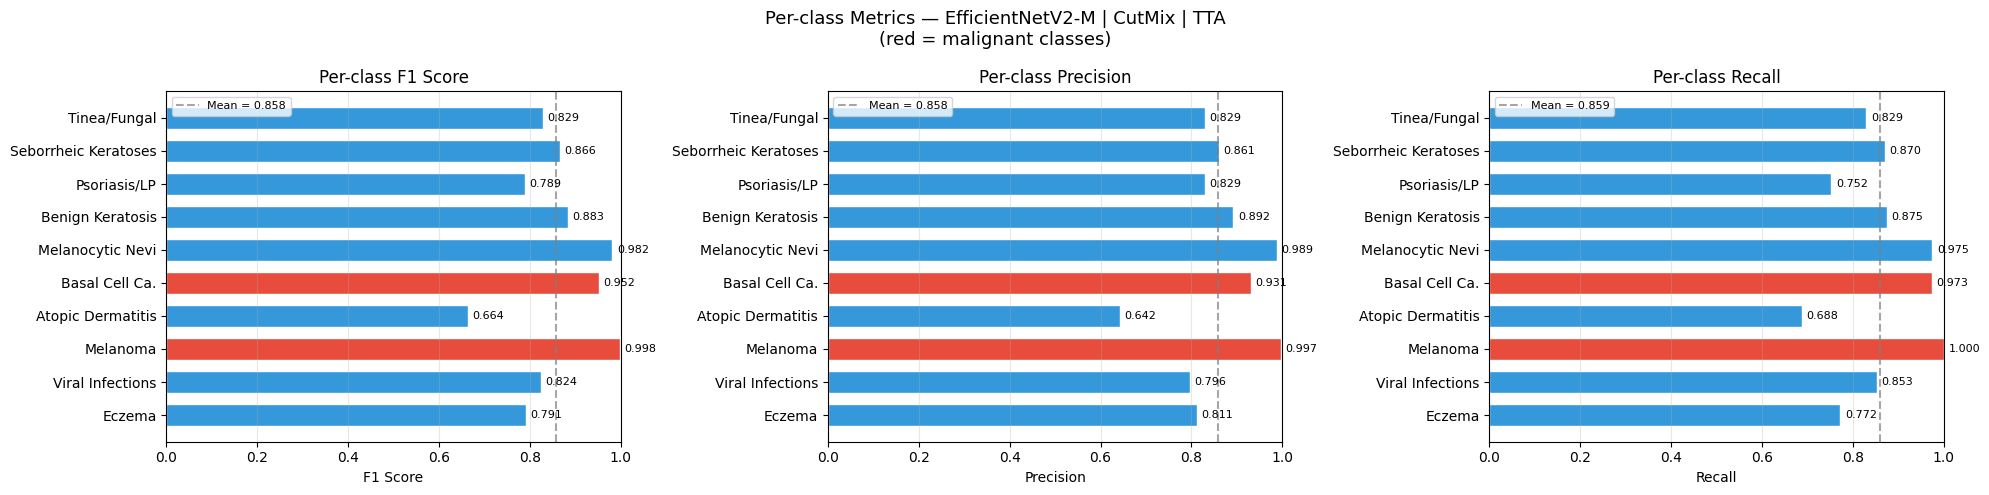


All outputs saved to: F:\ExcelTech-Take Home\output/

Training complete.
{
  "model": "efficientnet_v2_m",
  "image_size": 480,
  "augmentation": "cutmix",
  "tta_n": 5,
  "test_accuracy_single": 0.8932,
  "test_accuracy_tta": 0.9017,
  "test_weighted_f1_single": 0.893,
  "test_weighted_f1_tta": 0.9018,
  "best_val_f1": 0.9045
}


In [22]:
if __name__ == "__main__":
    model, history, results = train(CFG)
    print("\nTraining complete.")
    print(json.dumps(results, indent=2))